Customer Churn Prediction & Lifetime Value (LTV) Engine

In [69]:
#Import libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")


In [70]:
#load datset
df = pd.read_csv("../data/cleaned/encoded_telco.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,0,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,1,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,1,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,1,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,0,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [71]:
#dataset info
print("Shape :", df.shape)

df.info()

Shape : (7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
customerID          7043 non-null object
gender              7043 non-null int64
SeniorCitizen       7043 non-null int64
Partner             7043 non-null object
Dependents          7043 non-null object
tenure              7043 non-null int64
PhoneService        7043 non-null object
MultipleLines       7043 non-null object
InternetService     7043 non-null object
OnlineSecurity      7043 non-null object
OnlineBackup        7043 non-null object
DeviceProtection    7043 non-null object
TechSupport         7043 non-null object
StreamingTV         7043 non-null object
StreamingMovies     7043 non-null object
Contract            7043 non-null object
PaperlessBilling    7043 non-null object
PaymentMethod       7043 non-null object
MonthlyCharges      7043 non-null float64
TotalCharges        7043 non-null float64
Churn               7043 non-null int64
dtypes: float64

In [72]:
#check missing values
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [ ]:
#stastics
df.describe()

,gender,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.504756,0.162147,32.371149,64.761692,2281.916928,0.265370
std,0.500013,0.368612,24.559481,30.090047,2265.270398,0.441561
min,0.000000,0.000000,0.000000,18.250000,18.800000,0.000000
25%,0.000000,0.000000,9.000000,35.500000,402.225000,0.000000
50%,1.000000,0.000000,29.000000,70.350000,1397.475000,0.000000
75%,1.000000,0.000000,55.000000,89.850000,3786.600000,1.000000
max,1.000000,1.000000,72.000000,118.750000,8684.800000,1.000000


In [20]:
#column names
print(df.columns)

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


In [73]:
#feature engineering
df["AvgMonthlySpend"] = df["TotalCharges"]/(df["tenure"]+1)

df["IsLongTerm"]=(df["tenure"]>24).astype(int)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,AvgMonthlySpend,IsLongTerm
0,7590-VHVEG,0,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,14.925000,0
1,5575-GNVDE,1,0,No,No,34,Yes,No,DSL,Yes,...,No,No,One year,No,Mailed check,56.95,1889.50,0,53.985714,1
2,3668-QPYBK,1,0,No,No,2,Yes,No,DSL,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,36.050000,0
3,7795-CFOCW,1,0,No,No,45,No,No phone service,DSL,Yes,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,40.016304,1
4,9237-HQITU,0,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,50.550000,0


In [74]:
#remove customerid
df=df.drop("customerID",axis=1)

In [75]:
#encoding remaining columns
df=pd.get_dummies(df,drop_first=True)

df.head()

,gender,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,AvgMonthlySpend,IsLongTerm,Partner_Yes,Dependents_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,29.85,29.85,0,14.925000,0,1,0,...,0,0,0,0,0,0,1,0,1,0
1,1,0,34,56.95,1889.50,0,53.985714,1,0,0,...,0,0,0,0,1,0,0,0,0,1
2,1,0,2,53.85,108.15,1,36.050000,0,0,0,...,0,0,0,0,0,0,1,0,0,1
3,1,0,45,42.30,1840.75,0,40.016304,1,0,0,...,0,0,0,0,1,0,0,0,0,0
4,0,0,2,70.70,151.65,1,50.550000,0,0,0,...,0,0,0,0,0,0,1,0,1,0


In [76]:
#datatype
df.dtypes

gender                                     int64
SeniorCitizen                              int64
tenure                                     int64
MonthlyCharges                           float64
TotalCharges                             float64
Churn                                      int64
AvgMonthlySpend                          float64
IsLongTerm                                 int32
Partner_Yes                                uint8
Dependents_Yes                             uint8
PhoneService_Yes                           uint8
MultipleLines_No phone service             uint8
MultipleLines_Yes                          uint8
InternetService_Fiber optic                uint8
InternetService_No                         uint8
OnlineSecurity_No internet service         uint8
OnlineSecurity_Yes                         uint8
OnlineBackup_No internet service           uint8
OnlineBackup_Yes                           uint8
DeviceProtection_No internet service       uint8
DeviceProtection_Yes

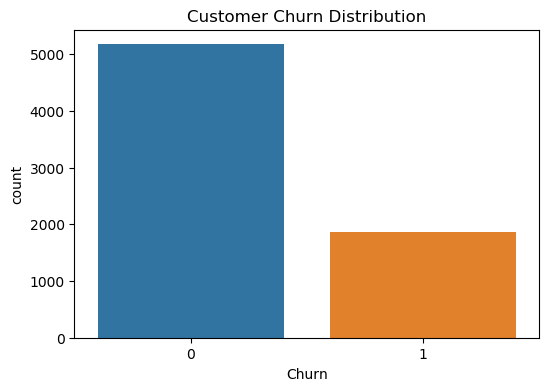

In [77]:
#churn distrubition
plt.figure(figsize=(6,4))

sns.countplot(x="Churn",data=df)

plt.title("Customer Churn Distribution")

plt.show()

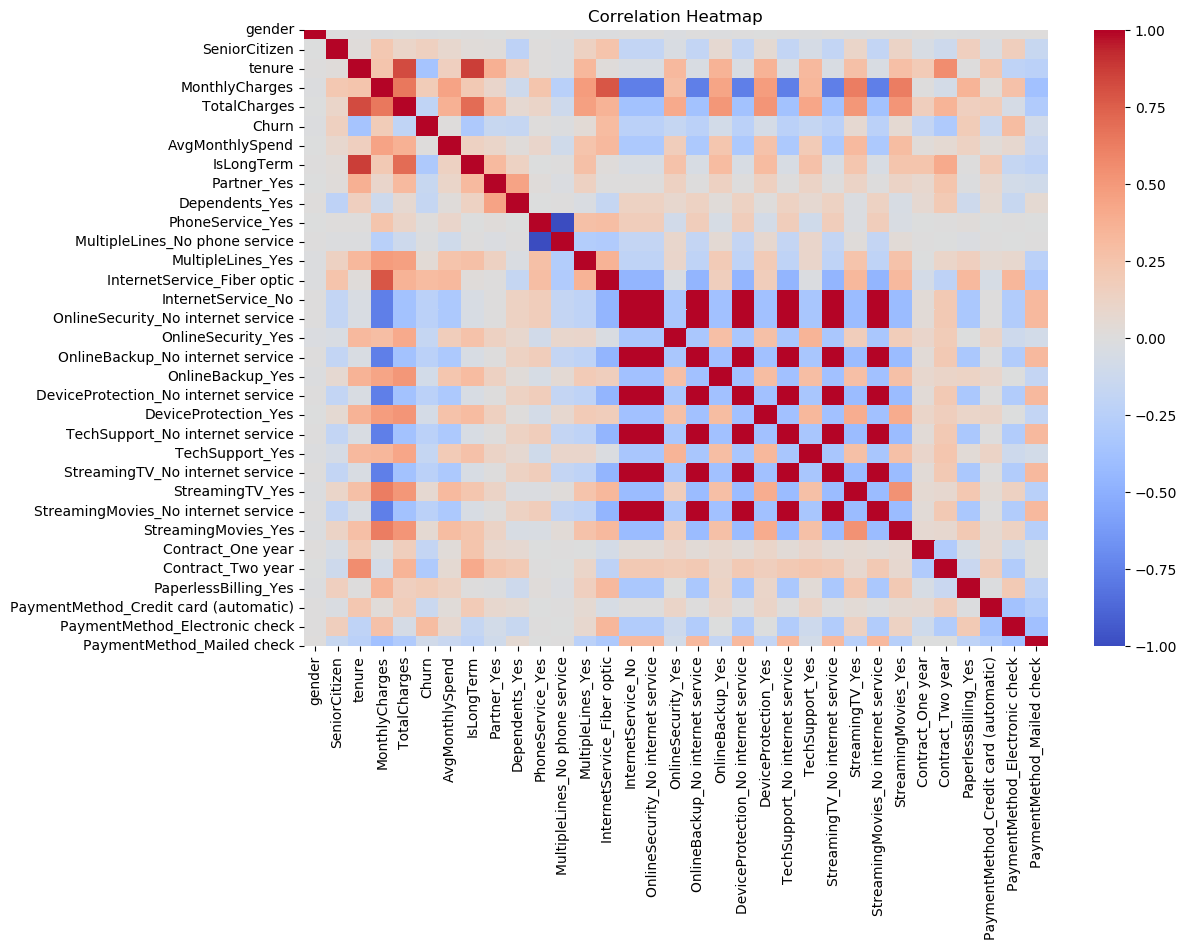

In [78]:
#Correlation Heatmap
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(),
            cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

In [79]:
#split dataset
from sklearn.model_selection import train_test_split

X=df.drop("Churn",axis=1)

y=df["Churn"]

X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [80]:
#logistic Regression
from sklearn.linear_model import LogisticRegression

model_lr=LogisticRegression(max_iter=1000)

model_lr.fit(X_train,y_train)

y_pred_lr=model_lr.predict(X_test)

In [ ]:
#logistic regression metrics
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

acc_lr=accuracy_score(y_test,y_pred_lr)
pre_lr=precision_score(y_test,y_pred_lr)
rec_lr=recall_score(y_test,y_pred_lr)
f1_lr=f1_score(y_test,y_pred_lr)

print(acc_lr)
print(pre_lr)
print(rec_lr)
print(f1_lr)

0.8090844570617459
0.6830985915492958
0.5201072386058981
0.5905631659056316


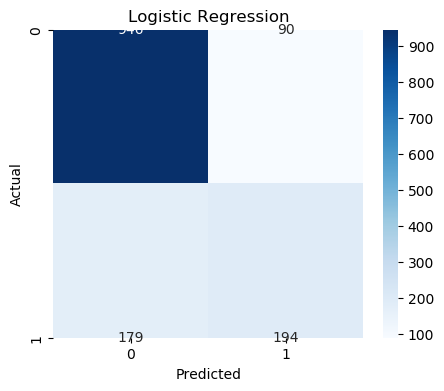

In [82]:
#lr confusion matrix
from sklearn.metrics import confusion_matrix

cm=confusion_matrix(y_test,y_pred_lr)

plt.figure(figsize=(5,4))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Logistic Regression")

plt.show()

In [83]:
#Random forest
from sklearn.ensemble import RandomForestClassifier

rf_model=RandomForestClassifier(random_state=42)

rf_model.fit(X_train,y_train)

y_pred_rf=rf_model.predict(X_test)

In [84]:
#rf metrics
acc_rf=accuracy_score(y_test,y_pred_rf)
pre_rf=precision_score(y_test,y_pred_rf)
rec_rf=recall_score(y_test,y_pred_rf)
f1_rf=f1_score(y_test,y_pred_rf)

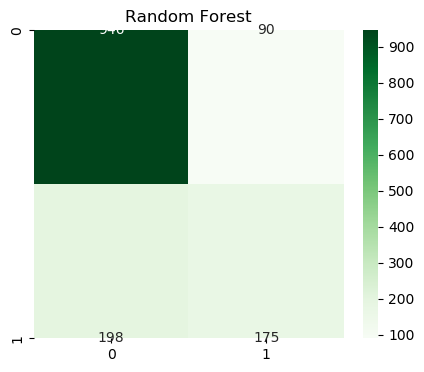

In [85]:
#rf confusion matrix
cm=confusion_matrix(y_test,y_pred_rf)

plt.figure(figsize=(5,4))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Greens")

plt.title("Random Forest")

plt.show()

In [86]:
#XGBoost
from xgboost import XGBClassifier

xgb_model=XGBClassifier(eval_metric="logloss")

xgb_model.fit(X_train,y_train)

y_pred_xgb=xgb_model.predict(X_test)

In [87]:
#xgb metrics
acc_xgb=accuracy_score(y_test,y_pred_xgb)
pre_xgb=precision_score(y_test,y_pred_xgb)
rec_xgb=recall_score(y_test,y_pred_xgb)
f1_xgb=f1_score(y_test,y_pred_xgb)

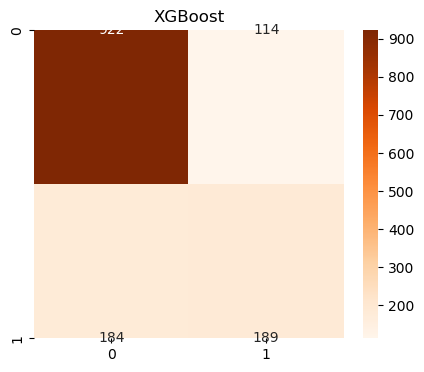

In [88]:
#xgb confusion matix
cm=confusion_matrix(y_test,y_pred_xgb)

plt.figure(figsize=(5,4))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Oranges")

plt.title("XGBoost")

plt.show()

In [89]:
#model comparision
comparison=pd.DataFrame({

"Model":[
"Logistic Regression",
"Random Forest",
"XGBoost"
],

"Accuracy":[acc_lr,acc_rf,acc_xgb],

"Precision":[pre_lr,pre_rf,pre_xgb],

"Recall":[rec_lr,rec_rf,rec_xgb],

"F1 Score":[f1_lr,f1_rf,f1_xgb]

})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.809084,0.683099,0.520107,0.590563
1,Random Forest,0.795600,0.660377,0.469169,0.548589
2,XGBoost,0.788502,0.623762,0.506702,0.559172


In [90]:
#save comparision
comparison.to_csv("../reports/model_comparison.csv",index=False)

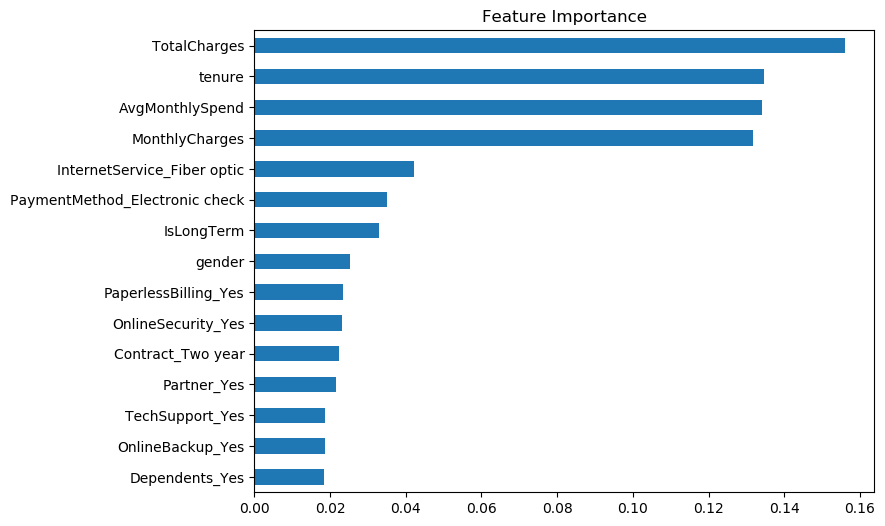

In [91]:
#feature importance
importance=pd.Series(
rf_model.feature_importances_,
index=X.columns
)

importance.sort_values().tail(15).plot(
kind="barh",
figsize=(8,6)
)

plt.title("Feature Importance")

plt.show()

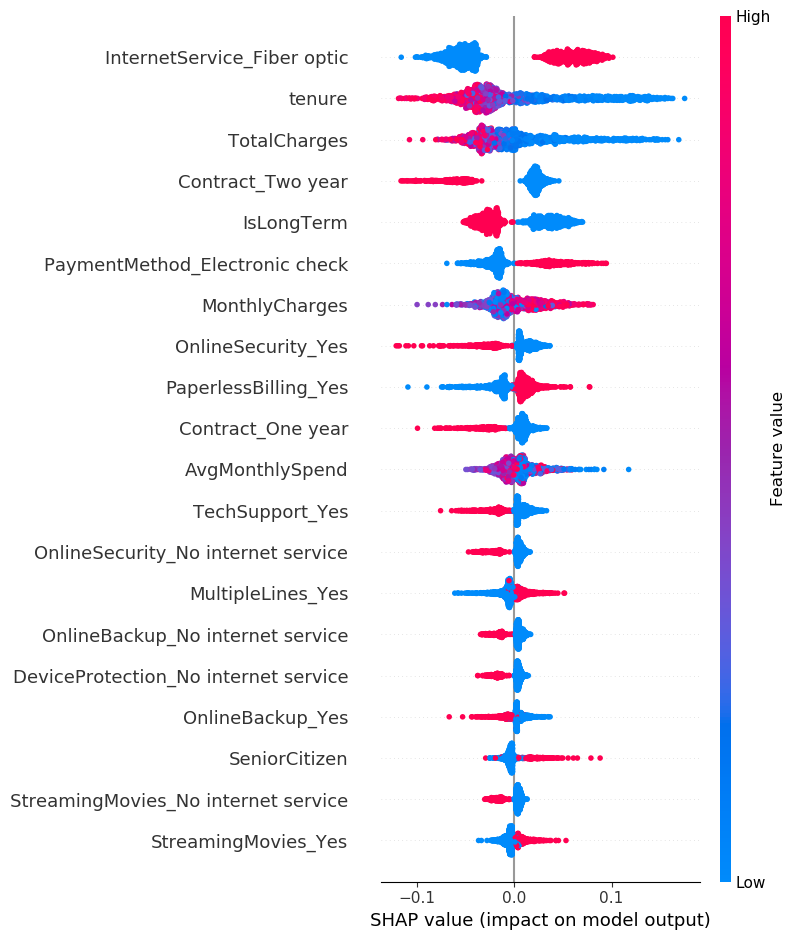

In [92]:
#shap analysis
import shap

explainer=shap.TreeExplainer(rf_model)

shap_values=explainer.shap_values(X_test)

shap.summary_plot(shap_values[1],X_test)

In [93]:
#save bestmodel
import joblib

joblib.dump(model_lr,"../models/best_model.pkl")

['../models/best_model.pkl']

In [94]:
#create ltv column
df["LTV"]=df["MonthlyCharges"]*df["tenure"]

df[["MonthlyCharges","tenure","LTV"]].head()

,MonthlyCharges,tenure,LTV
0,29.85,1,29.85
1,56.95,34,1936.30
2,53.85,2,107.70
3,42.30,45,1903.50
4,70.70,2,141.40


In [95]:
#ltv preditiction
from sklearn.ensemble import RandomForestRegressor

X=df.drop("LTV",axis=1)

y=df["LTV"]

X_train,X_test,y_train,y_test=train_test_split(
X,
y,
test_size=0.2,
random_state=42
)

regressor=RandomForestRegressor(random_state=42)

regressor.fit(X_train,y_train)

pred=regressor.predict(X_test)

In [96]:
#evaluate ltv
from sklearn.metrics import mean_absolute_error

print("MAE :",mean_absolute_error(y_test,pred))

MAE : 40.841619588360494


# Conclusion

- Loaded and cleaned the Telco Customer Churn dataset.
- Performed exploratory data analysis (EDA) and feature engineering.
- Encoded categorical variables and prepared the dataset for machine learning.
- Trained Logistic Regression, Random Forest, and XGBoost models.
- Compared the models using Accuracy, Precision, Recall, and F1 Score.
- Logistic Regression achieved the best overall performance with an accuracy of **80.91%**.
- Used SHAP analysis to understand the important features affecting customer churn.
- Built a Customer Lifetime Value (LTV) prediction model.
- Saved the trained models for future deployment.
- The project provides a useful solution for predicting customer churn and supporting customer retention strategies.